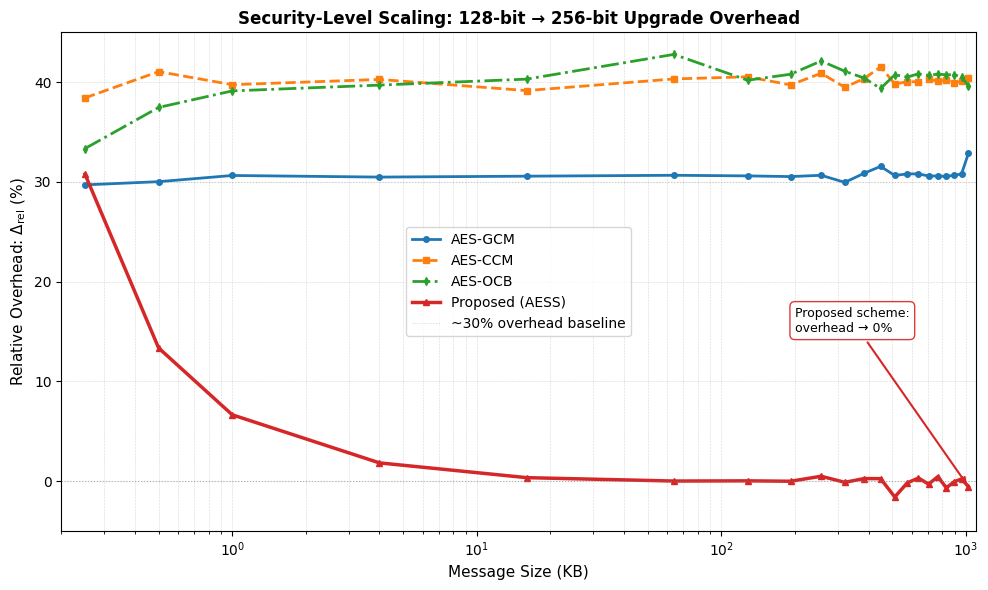

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Data from benchmarks
sizes_kb = np.array([0.25, 0.5, 1, 4, 16, 64, 128, 192, 256, 320, 384, 448, 512, 576, 640, 704, 768, 832, 896, 960, 1024])

# Relative overhead (%) for each scheme
gcm_overhead = np.array([29.71, 30.03, 30.65, 30.49, 30.58, 30.67, 30.61, 30.54, 30.67, 29.96, 30.88, 31.56, 30.65, 30.81, 30.81, 30.60, 30.60, 30.56, 30.67, 30.81, 32.86])
ccm_overhead = np.array([38.43, 41.06, 39.75, 40.28, 39.16, 40.33, 40.54, 39.73, 40.90, 39.49, 40.37, 41.54, 39.83, 40.04, 40.05, 40.31, 40.11, 40.23, 39.90, 40.11, 40.45])
ocb_overhead = np.array([33.35, 37.47, 39.13, 39.71, 40.31, 42.79, 40.20, 40.80, 42.13, 41.10, 40.41, 39.37, 40.75, 40.52, 40.84, 40.68, 40.81, 40.74, 40.76, 40.50, 39.67])
proposed_overhead = np.array([30.78, 13.36, 6.66, 1.84, 0.36, 0.02, 0.04, 0.00, 0.50, -0.11, 0.27, 0.26, -1.58, -0.16, 0.32, -0.29, 0.46, -0.66, -0.05, 0.23, -0.54])

# Create the plot
plt.figure(figsize=(10, 6))
plt.semilogx(sizes_kb, gcm_overhead, 'o-', label='AES-GCM', linewidth=2, markersize=4, color='#1f77b4')
plt.semilogx(sizes_kb, ccm_overhead, 's--', label='AES-CCM', linewidth=2, markersize=4, color='#ff7f0e')
plt.semilogx(sizes_kb, ocb_overhead, 'd-.', label='AES-OCB', linewidth=2, markersize=4, color='#2ca02c')
plt.semilogx(sizes_kb, proposed_overhead, '^-', label='Proposed (AESS)', linewidth=2.5, markersize=5, color='#d62728')

# Reference lines
plt.axhline(y=0, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
plt.axhline(y=30, color='gray', linestyle=':', linewidth=0.8, alpha=0.3, label='~30% overhead baseline')

# Labels and styling
plt.xlabel('Message Size (KB)', fontsize=11)
plt.ylabel('Relative Overhead: $\\Delta_{\\mathrm{rel}}$ (%)', fontsize=11)
plt.title('Security-Level Scaling: 128-bit → 256-bit Upgrade Overhead', fontsize=12, fontweight='bold')
plt.legend(fontsize=10, frameon=True, shadow=False)
plt.grid(True, which='both', linestyle='--', linewidth=0.4, alpha=0.5)
plt.ylim(-5, 45)
plt.xlim(0.2, 1100)

# Annotation highlighting the key insight
plt.annotate('Proposed scheme:\noverhead → 0%', 
             xy=(1024, -0.54), xytext=(200, 15),
             arrowprops=dict(arrowstyle='->', color='#d62728', lw=1.5),
             fontsize=9, bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#d62728', alpha=0.9))

plt.tight_layout()
plt.savefig('security_scaling_overhead.pdf', bbox_inches='tight', dpi=300)
plt.savefig('security_scaling_overhead.png', bbox_inches='tight', dpi=300)
plt.show()